# Game Analytics Notebook

This notebook loads the exported game data, removes test accounts, and produces summary statistics, charts, and behavioral insights.

**Exclusions:** `test@gmail.com`, `test2@gmail.com` (and all sessions/traces for those accounts).

If the data file path changes, update the `data_path` cell below.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 120)

In [2]:
# Update this path if you move the data file
data_path = Path(r"e:\COLLEGE\HK251\DACN\Serious_Game_Scam\Analytics\data.json")

with data_path.open("r", encoding="utf-8") as f:
    data = json.load(f)

players_raw = data.get("players", {})
sessions_raw = data.get("sessions", {})

players_df = pd.DataFrame(players_raw.values())
if not players_df.empty:
    players_df["created_at"] = pd.to_datetime(players_df["created_at"], unit="ms", errors="coerce")

test_emails = {"test@gmail.com", "test2@gmail.com"}
test_player_ids = set(players_df.loc[players_df["email"].isin(test_emails), "userid"]) if not players_df.empty else set()
players_df = players_df[~players_df["email"].isin(test_emails)].copy()

sessions_rows = []
traces_rows = []
for session_id, s in sessions_raw.items():
    row = dict(s)
    row["session_id"] = session_id
    sessions_rows.append(row)

    for t in (s.get("traces", []) or []):
        trace_row = dict(t)
        trace_row["session_id"] = session_id
        trace_row["player_id"] = s.get("player_id")
        trace_row["session_start_time"] = s.get("start_time")
        trace_row["session_end_time"] = s.get("end_time")
        traces_rows.append(trace_row)

sessions_df = pd.DataFrame(sessions_rows)
traces_df = pd.DataFrame(traces_rows)

if not sessions_df.empty:
    sessions_df = sessions_df[~sessions_df["player_id"].isin(test_player_ids)].copy()
if not traces_df.empty:
    traces_df = traces_df[~traces_df["player_id"].isin(test_player_ids)].copy()

for col in ["start_time", "end_time"]:
    if col in sessions_df.columns:
        sessions_df[col] = pd.to_datetime(sessions_df[col], unit="ms", errors="coerce")

if "timestamp" in traces_df.columns:
    traces_df["timestamp"] = pd.to_datetime(traces_df["timestamp"], unit="ms", errors="coerce")
if "session_start_time" in traces_df.columns:
    traces_df["session_start_time"] = pd.to_datetime(traces_df["session_start_time"], unit="ms", errors="coerce")
if "session_end_time" in traces_df.columns:
    traces_df["session_end_time"] = pd.to_datetime(traces_df["session_end_time"], unit="ms", errors="coerce")

if "final_scores" in sessions_df.columns:
    final_scores_df = pd.json_normalize(sessions_df["final_scores"]).add_prefix("final_")
    sessions_df = pd.concat([sessions_df.drop(columns=["final_scores"]), final_scores_df], axis=1)

if "score_state" in traces_df.columns:
    score_state_df = pd.json_normalize(traces_df["score_state"]).add_prefix("state_")
    traces_df = pd.concat([traces_df.drop(columns=["score_state"]), score_state_df], axis=1)

if not players_df.empty:
    sessions_df = sessions_df.merge(players_df[["userid", "email"]], left_on="player_id", right_on="userid", how="left").drop(columns=["userid"])
    traces_df = traces_df.merge(players_df[["userid", "email"]], left_on="player_id", right_on="userid", how="left").drop(columns=["userid"])

players_df.head(), sessions_df.head(), traces_df.head()

(               created_at               email                        userid
 0 2026-05-31 12:04:21.876  player12@gmail.com  1gJPPFrwADbPzDMNxwIhKHuCPWv1
 1 2026-05-31 10:53:51.276  player10@gmail.com  40f1uksF5kYFvJ5WxoYBzlBCfBE2
 3 2026-05-31 04:26:14.930   player5@gmail.com  EOOUznHcdYM3B5Eu7H7303gt3Nl1
 4 2026-05-31 04:01:29.650   player3@gmail.com  Phcnngo3Fddhr78h6wLbEE8qeW22
 5 2026-05-31 11:01:42.996  player11@gmail.com  VYZqyGu79USyXvpxpxWmk0lxnAE3,
                  end_time is_completed                     player_id  \
 0 2026-05-31 10:12:05.581        False  dhiHXvJmYgaNYeeE3QVoo77dMwf1   
 1 2026-05-31 11:11:29.933         True  vYmu30ZTOHbjiC4mPuaw73q6pZf1   
 2 2026-05-31 11:28:46.602         True  VYZqyGu79USyXvpxpxWmk0lxnAE3   
 3 2026-05-31 11:14:40.951         True  40f1uksF5kYFvJ5WxoYBzlBCfBE2   
 4 2026-05-31 12:12:39.638         True  1gJPPFrwADbPzDMNxwIhKHuCPWv1   
 
                          session_id              start_time  \
 0  1d326bc28e284f6f8fb09faf60f25

In [3]:
# Basic overview
num_players = players_df["userid"].nunique() if not players_df.empty else 0
num_sessions = len(sessions_df)
num_traces = len(traces_df)
completion_rate = sessions_df["is_completed"].mean() if "is_completed" in sessions_df.columns and num_sessions > 0 else np.nan

print(f"Players (non-test): {num_players}")
print(f"Sessions (non-test): {num_sessions}")
print(f"Traces (non-test): {num_traces}")
print(f"Completion rate: {completion_rate:.2%}" if pd.notna(completion_rate) else "Completion rate: N/A")

if "total_playtime_seconds" in sessions_df.columns and num_sessions > 0:
    print("Playtime (sec) - mean/median/min/max:",
          sessions_df["total_playtime_seconds"].mean(),
          sessions_df["total_playtime_seconds"].median(),
          sessions_df["total_playtime_seconds"].min(),
          sessions_df["total_playtime_seconds"].max())

Players (non-test): 11
Sessions (non-test): 29
Traces (non-test): 241
Completion rate: 70.59%
Playtime (sec) - mean/median/min/max: 1020.2276470588234 950.325 4.916 3510.053


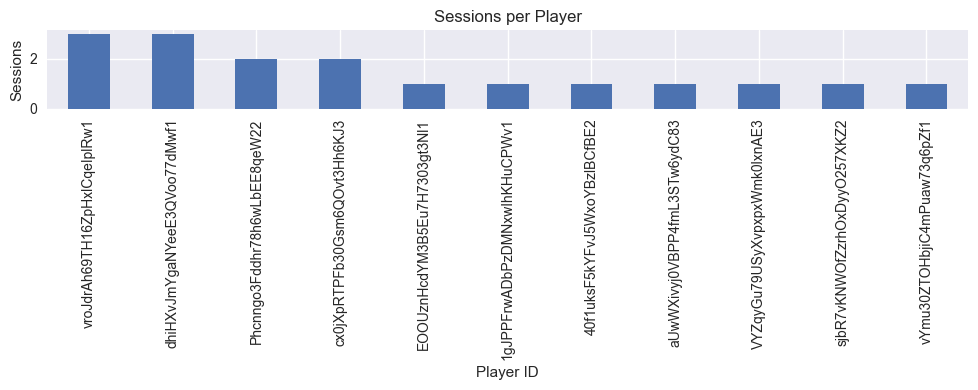

In [4]:
# Sessions per player
if not sessions_df.empty:
    sessions_per_player = sessions_df.groupby("player_id").size().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sessions_per_player.plot(kind="bar")
    plt.title("Sessions per Player")
    plt.xlabel("Player ID")
    plt.ylabel("Sessions")
    plt.tight_layout()
    plt.show()

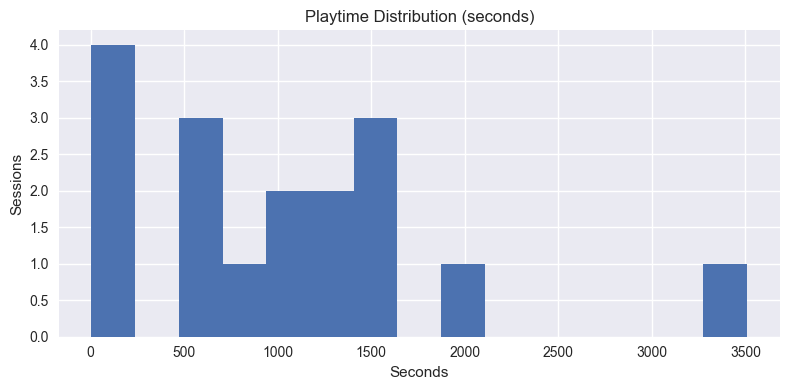

In [5]:
# Playtime distribution
if "total_playtime_seconds" in sessions_df.columns and not sessions_df.empty:
    plt.figure(figsize=(8, 4))
    sessions_df["total_playtime_seconds"].hist(bins=15)
    plt.title("Playtime Distribution (seconds)")
    plt.xlabel("Seconds")
    plt.ylabel("Sessions")
    plt.tight_layout()
    plt.show()

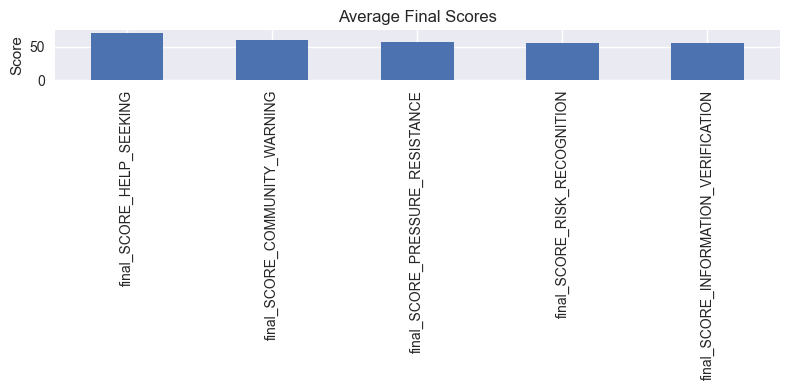

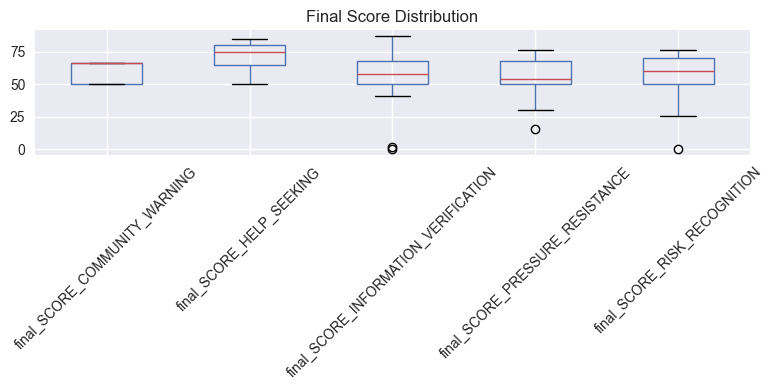

In [6]:
# Final score analysis
final_score_cols = [c for c in sessions_df.columns if c.startswith("final_")]
if final_score_cols:
    score_means = sessions_df[final_score_cols].mean().sort_values(ascending=False)
    plt.figure(figsize=(8, 4))
    score_means.plot(kind="bar")
    plt.title("Average Final Scores")
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sessions_df[final_score_cols].boxplot(rot=45)
    plt.title("Final Score Distribution")
    plt.tight_layout()
    plt.show()

,trace_id,count
0,TRACE_ASK_PERSON,64
1,TRACE_REFUSE_RISKY_REQUEST,29
2,TRACE_INSPECT_SOURCE,22
3,TRACE_WARN_OTHERS,19
4,TRACE_READ_RELEVANT_INFO,11
5,TRACE_TRANSFER_MONEY,9
6,TRACE_DETECT_RED_FLAG,7
7,TRACE_OPEN_UNVERIFIED_LINK,6
8,TRACE_DELAY_ACTION,5
9,TRACE_OPEN_UNVERIFIED_FORM,4


,route_id,count
0,CH1_M0_R0_BB_3,12
1,CH1_M1_R0_BB_3,12
2,CH1_M0_R0_BB_13,12
3,CH1_M2_R0_BB_3,12
4,CH1_M3_R0_BB_5,12
5,CH1_M0_R0_BB_4,11
6,CH1_M0_R0_BB_1,11
7,CH1_M3_R0_BB_2,10
8,CH1_M4_R3_BB_1,9
9,CH1_M4_R3_BB_2,9


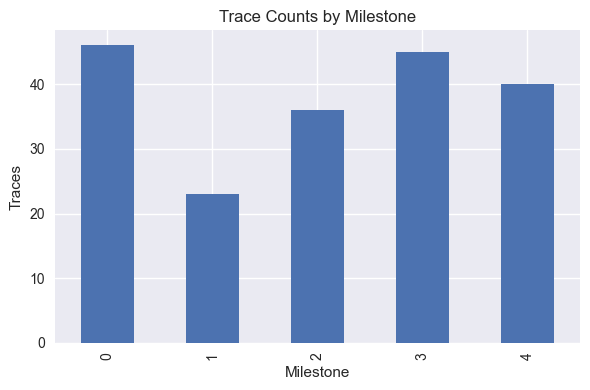

In [7]:
# Trace analysis: top trace_id and route_id
if not traces_df.empty:
    top_traces = traces_df["trace_id"].value_counts().head(10)
    top_routes = traces_df["route_id"].value_counts().head(10)

    display(pd.DataFrame({"trace_id": top_traces.index, "count": top_traces.values}))
    display(pd.DataFrame({"route_id": top_routes.index, "count": top_routes.values}))

    if "milestone_id" in traces_df.columns:
        milestone_counts = traces_df["milestone_id"].value_counts().sort_index()
        plt.figure(figsize=(6, 4))
        milestone_counts.plot(kind="bar")
        plt.title("Trace Counts by Milestone")
        plt.xlabel("Milestone")
        plt.ylabel("Traces")
        plt.tight_layout()
        plt.show()

trace_category
safe       157
unknown     51
risky       21
neutral     12
Name: count, dtype: int64

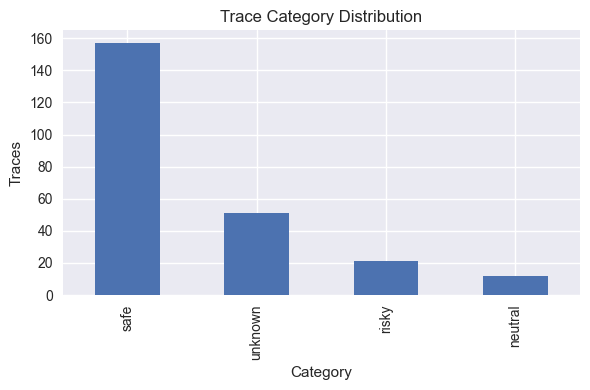

In [8]:
# Behavior labeling: simple safe vs risky heuristic based on trace_id
def classify_trace(trace_id):
    if not isinstance(trace_id, str):
        return "unknown"
    tid = trace_id.upper()
    safe_keys = ["REFUSE", "DETECT", "INSPECT", "VERIFY", "WARN", "ASK_PERSON", "DELAY", "READ_RELEVANT_INFO"]
    risky_keys = ["TRANSFER", "OPEN_UNVERIFIED", "IGNORE"]
    if any(k in tid for k in safe_keys):
        return "safe"
    if any(k in tid for k in risky_keys):
        return "risky"
    return "neutral"

if not traces_df.empty:
    traces_df["trace_category"] = traces_df["trace_id"].apply(classify_trace)
    category_counts = traces_df["trace_category"].value_counts()
    display(category_counts)

    plt.figure(figsize=(6, 4))
    category_counts.plot(kind="bar")
    plt.title("Trace Category Distribution")
    plt.xlabel("Category")
    plt.ylabel("Traces")
    plt.tight_layout()
    plt.show()

,delta_SCORE_COMMUNITY_WARNING,delta_SCORE_HELP_SEEKING,delta_SCORE_INFORMATION_VERIFICATION,delta_SCORE_PRESSURE_RESISTANCE,delta_SCORE_RISK_RECOGNITION
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,1.600000,-1.500000,-6.000000,-3.000000,-2.200000
std,5.059644,13.550318,19.333333,11.440668,11.554701
min,-8.000000,-35.000000,-50.000000,-20.000000,-24.000000
25%,0.000000,0.000000,-6.000000,-6.000000,-3.750000
50%,0.000000,0.000000,0.000000,-3.000000,0.000000
75%,6.000000,3.750000,3.500000,0.000000,0.000000
max,8.000000,15.000000,16.000000,20.000000,15.000000


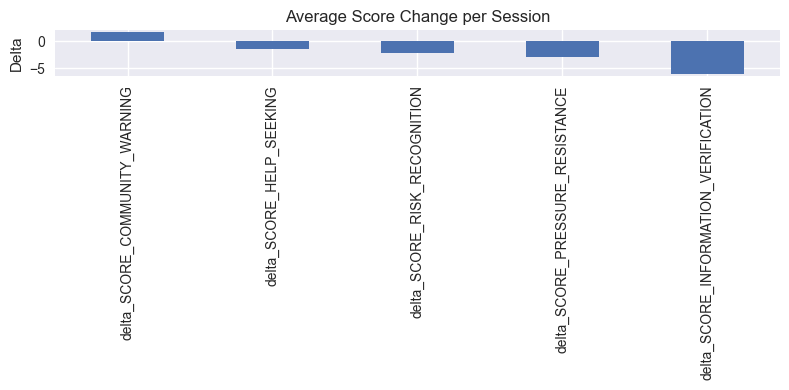

In [9]:
# Score change within each session (first trace -> last trace)
score_cols = [c for c in traces_df.columns if c.startswith("state_")]
if score_cols and "timestamp" in traces_df.columns:
    deltas = []
    for session_id, g in traces_df.sort_values("timestamp").groupby("session_id"):
        first = g.iloc[0][score_cols]
        last = g.iloc[-1][score_cols]
        delta = (last - first).rename(lambda x: x.replace("state_", "delta_"))
        row = {"session_id": session_id}
        row.update(delta.to_dict())
        deltas.append(row)

    deltas_df = pd.DataFrame(deltas)
    display(deltas_df.describe())

    if not deltas_df.empty:
        avg_delta = deltas_df.drop(columns=["session_id"]).mean().sort_values(ascending=False)
        plt.figure(figsize=(8, 4))
        avg_delta.plot(kind="bar")
        plt.title("Average Score Change per Session")
        plt.ylabel("Delta")
        plt.tight_layout()
        plt.show()

In [10]:
# Export cleaned data for reporting (optional)
output_dir = Path("analysis_outputs")
output_dir.mkdir(exist_ok=True)

players_df.to_csv(output_dir / "players_clean.csv", index=False)
sessions_df.to_csv(output_dir / "sessions_clean.csv", index=False)
traces_df.to_csv(output_dir / "traces_clean.csv", index=False)

print("Exported cleaned CSVs to", output_dir.resolve())

Exported cleaned CSVs to E:\COLLEGE\HK251\DACN\Serious_Game_Scam\Analytics\analysis_outputs
